# TerraSAR-X Image Processing and Visualization

This notebook demonstrates the loading, processing, and visualization of TerraSAR-X Synthetic Aperture Radar (SAR) images from the StripMap Single Look Slant Range Complex (SSC) data format.

We'll visualize 256x256 patches from the SAR image at each processing step to better understand how the data transforms through the pipeline.


## 1. Import Required Libraries

First, we'll import the necessary libraries and utility functions.


In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import struct
from scipy import signal, special

# Add the parent directory to the path to import from src
sys.path.append(os.path.join(os.getcwd(), '..'))

# Import our reimplemented SAR utilities
from src.utils.sar_utils import (
    cos2mat, normalize_sar, denormalize_sar, symetrisation_patch,
    store_data_and_plot, multilook, extract_patch
)

## 2. Define Paths to TerraSAR-X Data

We need to specify the paths to the TerraSAR-X data files.


In [2]:
# Base path to the TerraSAR-X data
base_data_path = Path("C:/Users/leon_ce/data/TSX/")

# Path to the specific image file (CoSAR format)
image_folder = base_data_path / "TSX_OPER_SAR_SM_SSC_20200918T055246_N50-693_E006-493_0000_v0102" / "dims_op_oc_dfd2_648438546_1" / "TSX-1.SAR.L1B" / "TSX1_SAR__SSC______SM_S_SRA_20200918T055246_20200918T055254" / "IMAGEDATA"
image_file = image_folder / "IMAGE_HH_SRA_strip_009.cos"


if not image_file.exists():
    # @TODO
    print("dick")
print(f"Image file path: {image_file}")

# Create output directory for temporary files if needed
# print(__file__) # Not available in notebooks
output_dir = Path(os.getcwd()) / "output"
os.makedirs(output_dir, exist_ok=True)
print(f"Output directory: {output_dir}")

Image file path: C:\Users\leon_ce\data\TSX\TSX_OPER_SAR_SM_SSC_20200918T055246_N50-693_E006-493_0000_v0102\dims_op_oc_dfd2_648438546_1\TSX-1.SAR.L1B\TSX1_SAR__SSC______SM_S_SRA_20200918T055246_20200918T055254\IMAGEDATA\IMAGE_HH_SRA_strip_009.cos
Output directory: c:\Users\leon_ce\dev\On-boardML\SAR_DDC\DDC_FPGA\notebooks\output


## 3. Helper Functions for Visualization

Let's define some helper functions for visualizing the SAR data at different stages of processing.


In [3]:
def visualize_complex_patch(complex_image, start_row, start_col, patch_size=256, title="Complex SAR Image"):
    """Visualize a patch from a complex SAR image (both magnitude and phase)"""
    patch = extract_patch(complex_image, start_row, start_col, patch_size)
    
    # Calculate magnitude and phase
    magnitude = np.abs(patch)
    phase = np.angle(patch)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot magnitude
    im1 = ax1.imshow(np.log(magnitude + 1e-10), cmap='gray')
    ax1.set_title(f"Magnitude (log scale)")
    plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
    
    # Plot phase
    im2 = ax2.imshow(phase, cmap='hsv')
    ax2.set_title(f"Phase")
    plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
    
    fig.suptitle(f"{title} - {patch_size}x{patch_size} Patch at ({start_row}, {start_col})")
    plt.tight_layout()
    plt.show()
    
    return patch

def visualize_real_imag_patch(real_part, imag_part, start_row, start_col, patch_size=256, title="Real and Imaginary Parts"):
    """Visualize real and imaginary parts of a SAR image patch"""
    real_patch = extract_patch(real_part, start_row, start_col, patch_size)
    imag_patch = extract_patch(imag_part, start_row, start_col, patch_size)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot real part
    im1 = ax1.imshow(real_patch, cmap='gray')
    ax1.set_title(f"Real Part")
    plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
    
    # Plot imaginary part
    im2 = ax2.imshow(imag_patch, cmap='gray')
    ax2.set_title(f"Imaginary Part")
    plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
    
    fig.suptitle(f"{title} - {patch_size}x{patch_size} Patch at ({start_row}, {start_col})")
    plt.tight_layout()
    plt.show()
    
    return real_patch, imag_patch

def visualize_normalized_patch(normalized_image, start_row, start_col, patch_size=256, title="Normalized SAR Image"):
    """Visualize a normalized SAR image patch"""
    patch = extract_patch(normalized_image, start_row, start_col, patch_size)
    
    plt.figure(figsize=(10, 8))
    im = plt.imshow(patch, cmap='gray')
    plt.title(f"{title} - {patch_size}x{patch_size} Patch at ({start_row}, {start_col})")
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()
    
    return patch

## 4. Load TerraSAR-X Image in CoSAR Format

Now we'll use the `cos2mat` function to load the TerraSAR-X image in CoSAR format.


In [4]:
# Load the CoSAR image
sar_data = cos2mat(image_file)
# print(sar_data) # Prints the full ndarray

# Check the shape of the loaded data
print(f"SAR data shape: {sar_data.shape}")
print(f"[:,:,0] contains the real part of the SLC image data")
print(f"[:,:,1] contains the imaginary part of the SLC image data")

# Extract real and imaginary parts
real_part = sar_data[:, :, 0]
imag_part = sar_data[:, :, 1]

# Reconstruct complex image
complex_image = real_part + 1j * imag_part

Converting CoSAR to numpy array of size [ncolumns,nlines,2]
Reading image in CoSAR format. ncolumns=21036 nlines=29828
[:,:,0] contains the real part of the SLC image data
[:,:,1] contains the imaginary part of the SLC image data
SAR data shape: (29828, 21036, 2)
[:,:,0] contains the real part of the SLC image data
[:,:,1] contains the imaginary part of the SLC image data


## 5. Visualize Raw SAR Image

Let's visualize a patch from the raw complex SAR image.


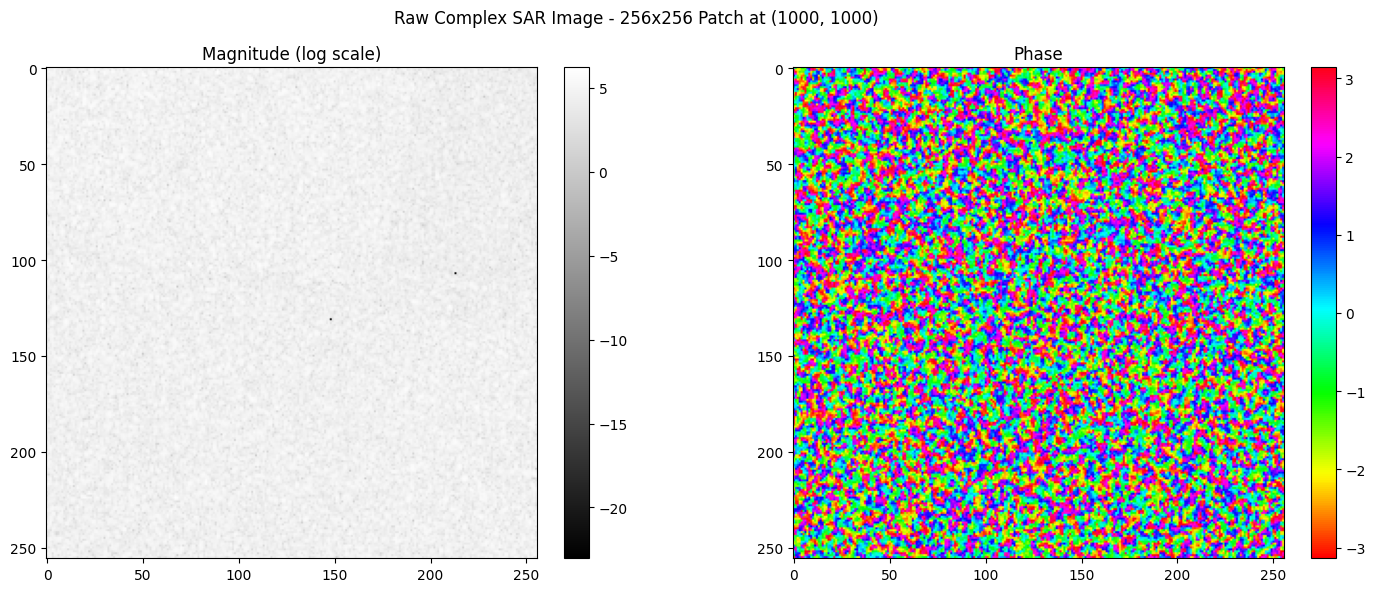

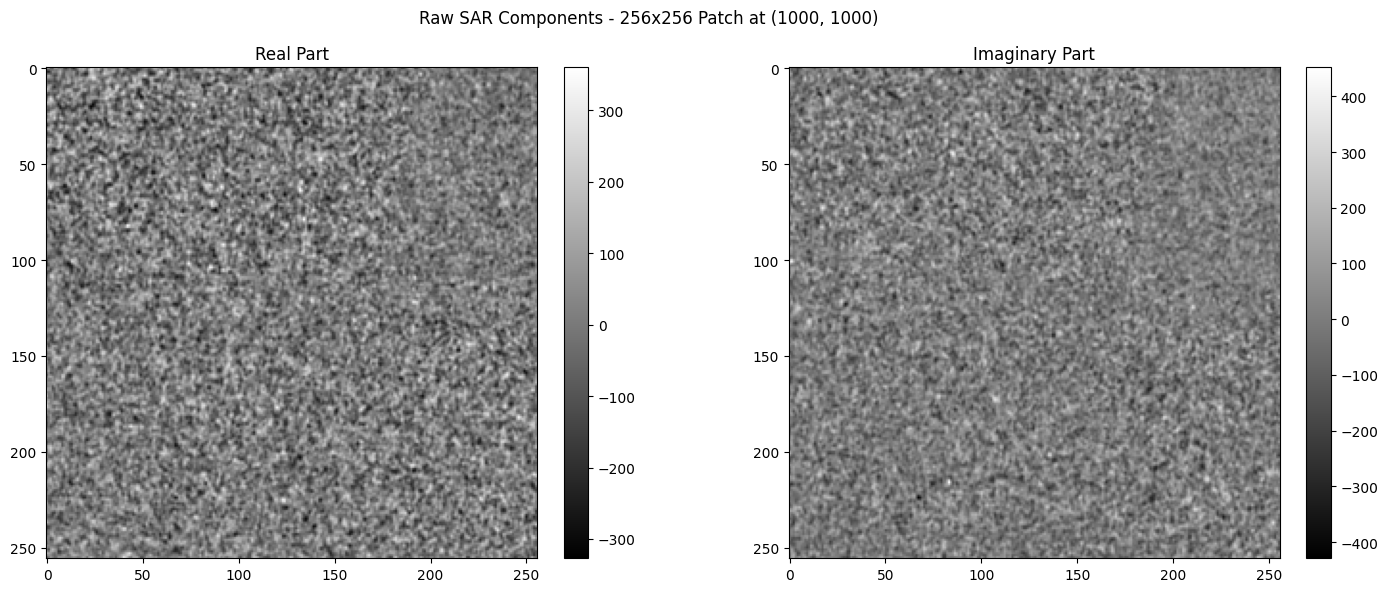

In [5]:
# Choose a patch location (adjust these values to explore different parts of the image)
start_row = 1000
start_col = 1000
patch_size = 256

# Visualize a patch from the complex image
complex_patch = visualize_complex_patch(complex_image, start_row, start_col, patch_size, "Raw Complex SAR Image")

# Also visualize real and imaginary parts separately
real_patch, imag_patch = visualize_real_imag_patch(real_part, imag_part, start_row, start_col, patch_size, "Raw SAR Components")

## 6. Calculate and Visualize Intensity Image

The intensity image is the squared magnitude of the complex image (I = |z|²).


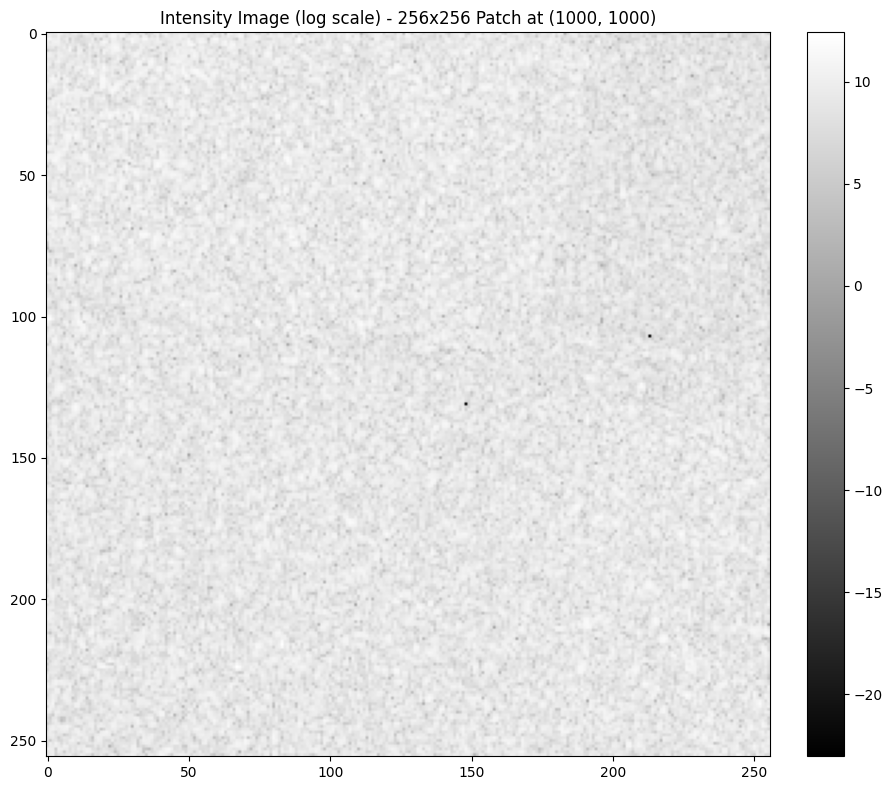

In [6]:
# Calculate intensity
intensity = np.abs(complex_image)**2

# Visualize intensity patch
plt.figure(figsize=(10, 8))
intensity_patch = extract_patch(intensity, start_row, start_col, patch_size)
im = plt.imshow(np.log(intensity_patch + 1e-10), cmap='gray')  # Log scale for better visualization
plt.title(f"Intensity Image (log scale) - {patch_size}x{patch_size} Patch at ({start_row}, {start_col})")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 7. Normalize the SAR Image

Now let's normalize the SAR image using our normalize_sar function.


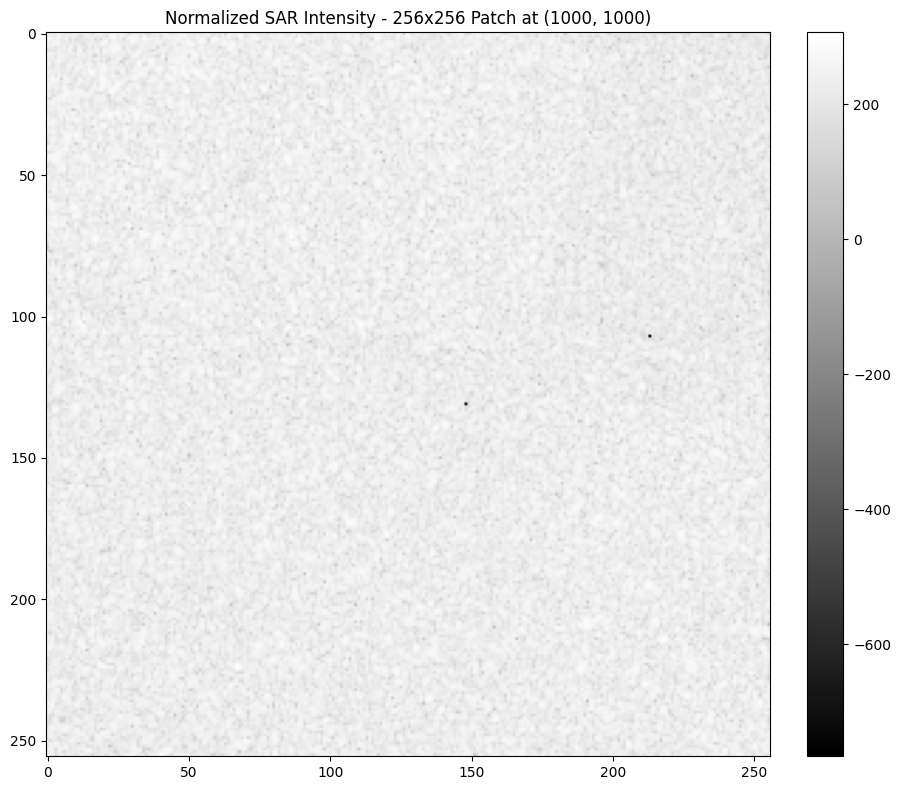

In [7]:
# Normalize the intensity image
normalized_intensity = normalize_sar(intensity)

# Visualize normalized patch
normalized_patch = visualize_normalized_patch(normalized_intensity, start_row, start_col, patch_size, "Normalized SAR Intensity")

# You can also denormalize if needed
# denormalized = denormalize_sar(normalized_intensity)

## 8. Speckle Analysis

SAR images are affected by speckle noise. Let's analyze the speckle characteristics in our patch.


Mean intensity: 13229.7383
Standard deviation: 13963.1758
Coefficient of variation: 1.0554
For fully developed speckle, CV should be close to 1.0 for amplitude and 0.5227 for intensity


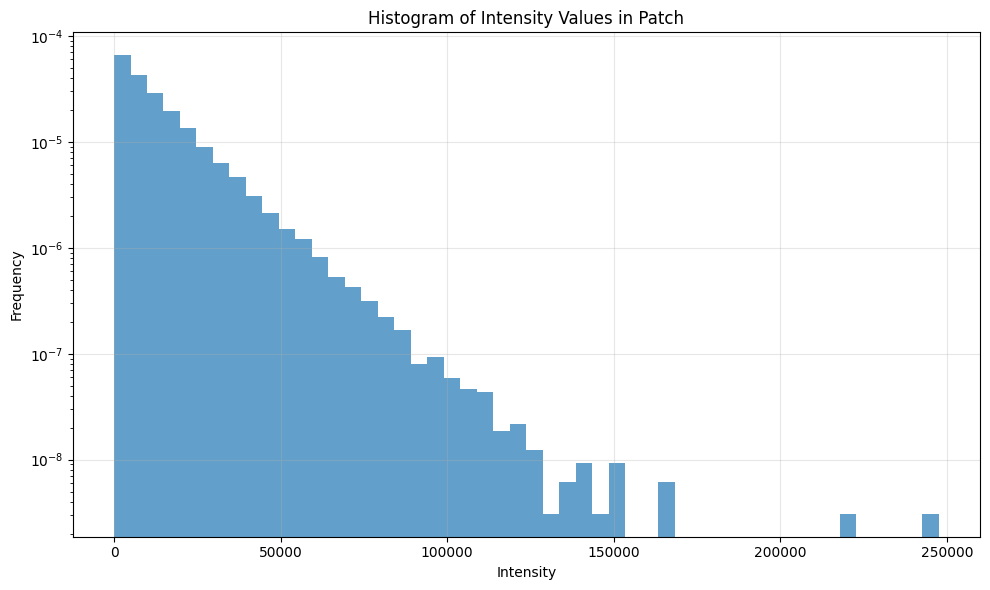

In [8]:
# Calculate statistics for the intensity patch
mean_intensity = np.mean(intensity_patch)
std_intensity = np.std(intensity_patch)
cv = std_intensity / mean_intensity  # Coefficient of variation

print(f"Mean intensity: {mean_intensity:.4f}")
print(f"Standard deviation: {std_intensity:.4f}")
print(f"Coefficient of variation: {cv:.4f}")
print(f"For fully developed speckle, CV should be close to 1.0 for amplitude and 0.5227 for intensity")

# Plot histogram of intensity values
plt.figure(figsize=(10, 6))
plt.hist(intensity_patch.flatten(), bins=50, alpha=0.7, density=True)
plt.title("Histogram of Intensity Values in Patch")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.yscale('log')  # Log scale for better visualization
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Multi-look Processing

Multi-look processing can help reduce speckle. Let's apply a simple multi-look process by averaging adjacent pixels.


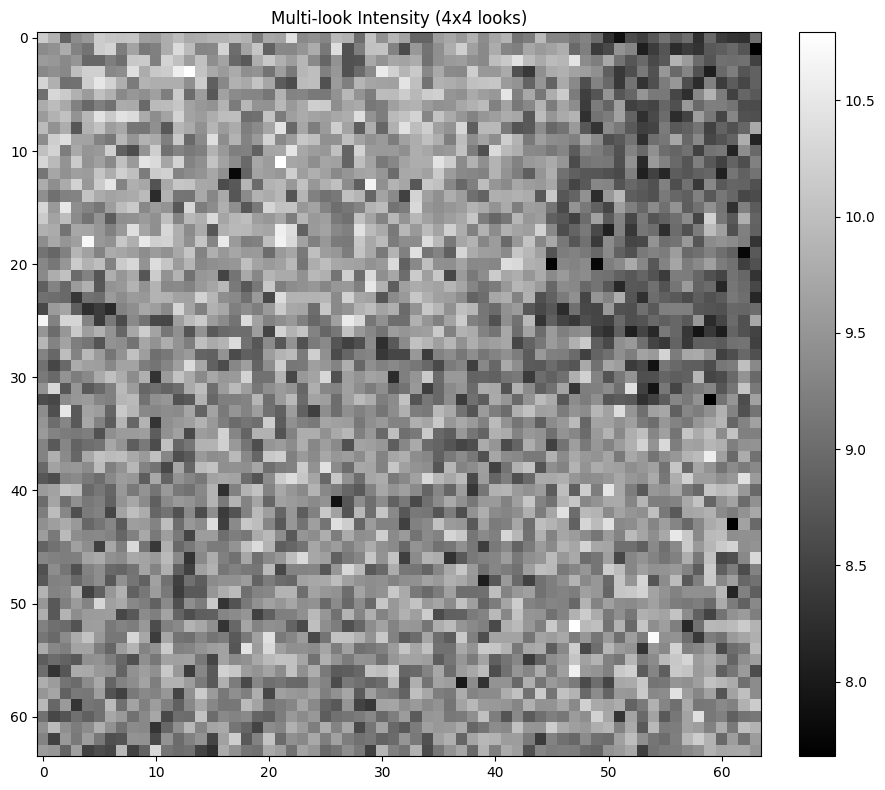

Multi-look CV: 0.4776 (should be lower than the original)


In [9]:
# Apply multi-look processing to the intensity patch
n_looks = 4  # Number of looks (adjust as needed)
multilook_patch = multilook(intensity_patch, n_looks)

# Visualize the multi-looked patch
plt.figure(figsize=(10, 8))
im = plt.imshow(np.log(multilook_patch + 1e-10), cmap='gray')  # Log scale for better visualization
plt.title(f"Multi-look Intensity ({n_looks}x{n_looks} looks)")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# Re-calculate coefficient of variation for multi-looked image
mean_ml = np.mean(multilook_patch)
std_ml = np.std(multilook_patch)
cv_ml = std_ml / mean_ml

print(f"Multi-look CV: {cv_ml:.4f} (should be lower than the original)")

## 10. Apply Symmetrization (Zero Doppler Centering)

Symmetrization is a common preprocessing step for SAR images to center the Doppler spectrum.


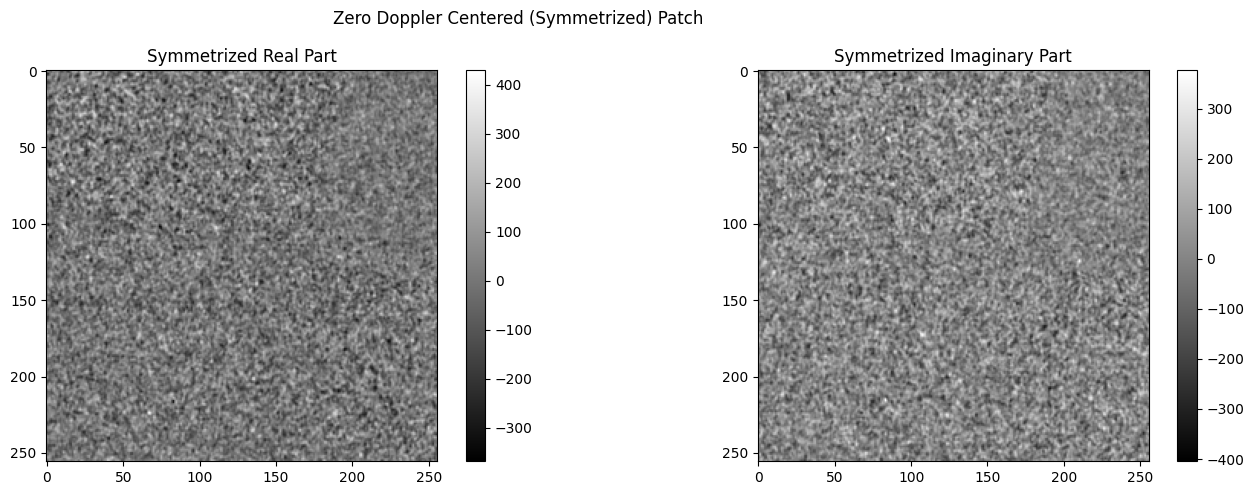

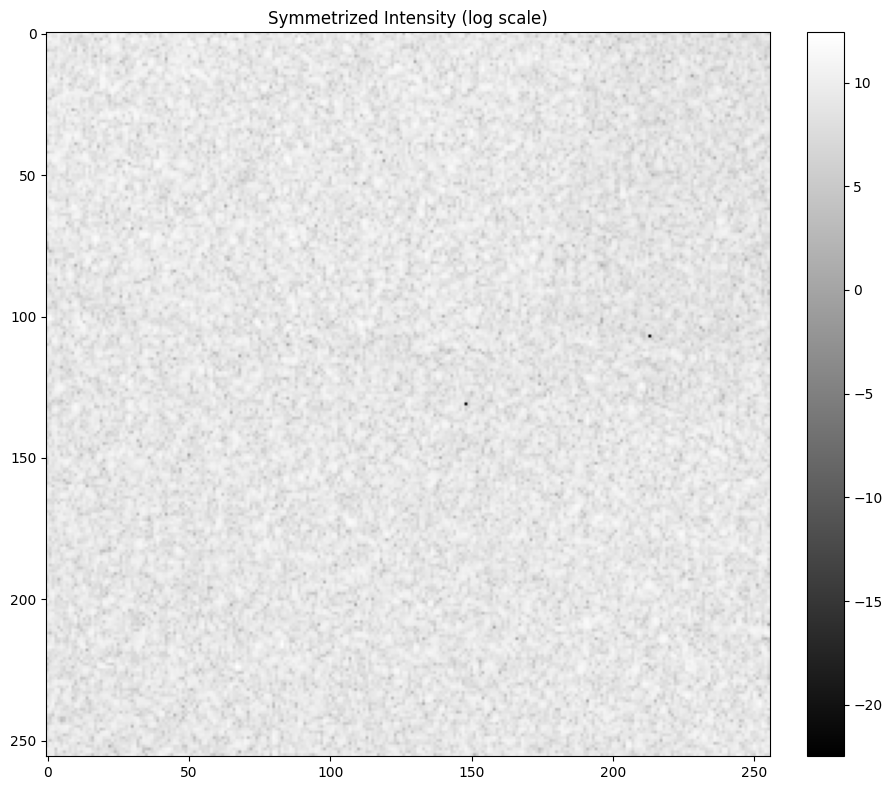

In [6]:
# Apply symmetrization to a small patch to avoid memory issues
patch_real = real_part[start_row:start_row+patch_size, start_col:start_col+patch_size]
patch_imag = imag_part[start_row:start_row+patch_size, start_col:start_col+patch_size]

# Reshape for symmetrization function
patch_real_reshaped = patch_real.reshape(1, patch_size, patch_size, 1)
patch_imag_reshaped = patch_imag.reshape(1, patch_size, patch_size, 1)

try:
    # Apply symmetrization
    sym_real, sym_imag = symetrisation_patch(patch_real_reshaped, patch_imag_reshaped)
    
    # Visualize symmetrized patch
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(sym_real[0, :, :, 0], cmap='gray')
    plt.title("Symmetrized Real Part")
    plt.colorbar(fraction=0.046, pad=0.04)
    
    plt.subplot(1, 2, 2)
    plt.imshow(sym_imag[0, :, :, 0], cmap='gray')
    plt.title("Symmetrized Imaginary Part")
    plt.colorbar(fraction=0.046, pad=0.04)
    
    plt.suptitle("Zero Doppler Centered (Symmetrized) Patch")
    plt.tight_layout()
    plt.show()
    
    # Reconstruct symmetrized complex image and calculate intensity
    sym_complex = sym_real[0, :, :, 0] + 1j * sym_imag[0, :, :, 0]
    sym_intensity = np.abs(sym_complex)**2
    
    # Visualize symmetrized intensity
    plt.figure(figsize=(10, 8))
    im = plt.imshow(np.log(sym_intensity + 1e-10), cmap='gray')
    plt.title("Symmetrized Intensity (log scale)")
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error in symmetrization: {e}")
    print("Skipping symmetrization step...")

## 11. Save Processed Images

Let's save the processed images for future use.


In [11]:
# Extract a larger region for saving (e.g., 1024x1024)
large_patch_size = 1024
large_start_row = max(0, start_row - (large_patch_size - patch_size) // 2)
large_start_col = max(0, start_col - (large_patch_size - patch_size) // 2)

# Make sure we don't go out of bounds
large_start_row = min(large_start_row, intensity.shape[0] - large_patch_size)
large_start_col = min(large_start_col, intensity.shape[1] - large_patch_size)

# Extract large patches
large_intensity_patch = extract_patch(intensity, large_start_row, large_start_col, large_patch_size)
large_real_patch = extract_patch(real_part, large_start_row, large_start_col, large_patch_size)
large_imag_patch = extract_patch(imag_part, large_start_row, large_start_col, large_patch_size)

# Save patches
np.save(os.path.join(output_dir, 'intensity_patch.npy'), large_intensity_patch)
np.save(os.path.join(output_dir, 'real_patch.npy'), large_real_patch)
np.save(os.path.join(output_dir, 'imag_patch.npy'), large_imag_patch)

# Save as images for quick viewing
# For intensity, apply log to enhance visualization
log_intensity = np.log(large_intensity_patch + 1e-10)
log_intensity_norm = (log_intensity - np.min(log_intensity)) / (np.max(log_intensity) - np.min(log_intensity)) * 255
intensity_image = Image.fromarray(log_intensity_norm.astype(np.uint8))
intensity_image.save(os.path.join(output_dir, 'intensity_patch.png'))

# For real and imaginary parts, normalize to 0-255 range
def normalize_for_image(arr):
    arr_norm = (arr - np.min(arr)) / (np.max(arr) - np.min(arr)) * 255
    return arr_norm.astype(np.uint8)

real_image = Image.fromarray(normalize_for_image(large_real_patch))
real_image.save(os.path.join(output_dir, 'real_patch.png'))

imag_image = Image.fromarray(normalize_for_image(large_imag_patch))
imag_image.save(os.path.join(output_dir, 'imag_patch.png'))

print(f"Saved processed patches to {output_dir}")

Saved processed patches to c:\Users\leon_ce\dev\On-boardML\SAR_DDC\DDC_FPGA\notebooks\output


## 12. Conclusion

In this notebook, we have:

1. Loaded a TerraSAR-X image in CoSAR format
2. Visualized the raw complex data (real and imaginary parts)
3. Calculated and visualized the intensity image
4. Normalized the SAR image
5. Analyzed speckle characteristics
6. Applied multi-look processing to reduce speckle
7. Applied symmetrization (Zero Doppler Centering)
8. Saved processed patches for future use

These steps provide a foundation for further SAR image processing and analysis, including despeckling and data compression as mentioned in the DDC_FPGA project.
